# 04 — Advanced Model: 1D-CNN on Raw Vibration Windows

**Goal.** Replace the hand-engineered 5-feature vector from notebook 02 with a 1D-CNN that learns features directly from the **raw 800-sample window**, and compare its three-class MCC against the Random Forest / XGBoost baselines from notebook 03.

**Why this matters for the project narrative.** The notebook 02 features encode strong domain priors — RMS, kurtosis, log-energy at three carefully chosen frequency bands. If the CNN beats the tree models, that's evidence the network is discovering something extra in the raw waveform beyond what the engineered features expose. If it doesn't, that's a useful negative result: on Set 2's outer-race-on-B1 failure, hand-engineered features are sufficient and the CNN's parameters are wasted capacity.

**Architecture.** Three 1D conv blocks with progressive downsampling, followed by adaptive pooling and a small dense head. Modelled after Kılıçkaya 2022 (corpus paper #1, Master's thesis on 1D Self-ONN / 1D CNN bearing fault diagnosis) and the hybrid 2DCNN-LSTM design in Pan et al. (corpus paper #12, *SHM* 2024).

**Comparability with notebook 03.** Same data splits (`split_strat`), same bearing-level labels (Normal for bearings 2–4 always; bearing 1 follows the EWMA labelling from notebook 02), same evaluation metrics (MCC, macro F1, per-class AP, confusion matrix).

In [1]:
from __future__ import annotations

import os
import time
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    matthews_corrcoef,
    f1_score,
    classification_report,
    confusion_matrix,
    average_precision_score,
)
from sklearn.preprocessing import label_binarize

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# --- device selection ---
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")
print(f"PyTorch {torch.__version__} | device: {DEVICE}")

torch.manual_seed(42)
np.random.seed(42)

# --- paths and constants ---
NB_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = NB_DIR.parent
FIG_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
DATA_ROOT = Path.home() / ".cache/kagglehub/datasets/vinayak123tyagi/bearing-dataset/versions/1"
SET2_DIR = DATA_ROOT / "2nd_test" / "2nd_test"

SAMPLE_RATE_HZ = 20_000
SAMPLES_PER_FILE = 20_480
WINDOW_SAMPLES = 800
WINDOWS_PER_FILE = SAMPLES_PER_FILE // WINDOW_SAMPLES

PyTorch 2.10.0.dev20251110 | device: mps


## 1. Load the feature matrix to reuse splits and labels

The feature matrix already encodes which row belongs to which split and what the bearing-level label is. We only need to re-extract the raw waveform that corresponds to each row.

In [2]:
feat_df = pd.read_parquet(PROCESSED_DIR / "set2_features.parquet")

# Bearing-level relabelling (same as notebook 03)
feat_df["state"] = np.where(feat_df["bearing"] == 1, feat_df["state_b1"], 0).astype("int8")

print(f"Rows: {len(feat_df):,}")
print(f"Class distribution: {dict(feat_df['state'].value_counts().sort_index())}")
print(f"Split distribution: {dict(feat_df['split_strat'].value_counts())}")

Rows: 98,400
Class distribution: {0: np.int64(87150), 1: np.int64(225), 2: np.int64(11025)}
Split distribution: {'train': np.int64(68800), 'val': np.int64(14800), 'test': np.int64(14800)}


## 2. Re-extract raw 40 ms windows for every row

The feature matrix tells us, for each (file × bearing × window_idx), what split and label it belongs to. We re-open the snapshot files and pull the corresponding 800-sample slice. The result is a tensor of shape `(N_windows, 1, 800)` that PyTorch can consume directly.

This takes ~1-2 minutes (984 files × disk read).

In [3]:
def list_snapshot_files(set_dir: Path) -> list[Path]:
    files = [p for p in set_dir.iterdir() if not p.name.startswith(".") and p.is_file()]
    files.sort(key=lambda p: p.name)
    return files


set2_files = list_snapshot_files(SET2_DIR)
file_path_by_name = {p.name: p for p in set2_files}
print(f"{len(set2_files)} snapshot files indexed")

984 snapshot files indexed


In [4]:
def load_snapshot(file_path: Path) -> np.ndarray:
    return np.loadtxt(file_path)


def build_window_tensors(feat_df: pd.DataFrame) -> dict[str, tuple[np.ndarray, np.ndarray]]:
    """Walk every snapshot file once, fill in windows for every (file, bearing, window_idx) row."""
    n_rows = len(feat_df)
    X = np.empty((n_rows, 1, WINDOW_SAMPLES), dtype=np.float32)
    y = feat_df["state"].to_numpy().astype(np.int64)
    splits = feat_df["split_strat"].to_numpy()

    # We need to know which row in feat_df corresponds to which (file, bearing, window_idx).
    # feat_df is already ordered by file then bearing then window_idx (from notebook 02's pipeline)
    # so we walk files and fill the tensor in-place.
    files_sorted = feat_df["file"].unique()  # preserves first-occurrence order
    row_ptr = 0
    t0 = time.time()
    for i, fname in enumerate(files_sorted):
        snap = load_snapshot(file_path_by_name[fname])
        n_rows_this_file = WINDOWS_PER_FILE * 4   # 25 windows × 4 bearings
        for bearing in range(4):
            sig = snap[:, bearing]
            for w_idx in range(WINDOWS_PER_FILE):
                X[row_ptr, 0] = sig[w_idx * WINDOW_SAMPLES:(w_idx + 1) * WINDOW_SAMPLES]
                row_ptr += 1
        if (i + 1) % 200 == 0 or i == len(files_sorted) - 1:
            dt = time.time() - t0
            print(f"  {i+1:4d}/{len(files_sorted)} files  | {dt:5.1f}s elapsed | {(i+1)/dt:4.1f} files/s")

    assert row_ptr == n_rows, f"row_ptr {row_ptr} != n_rows {n_rows}"

    out = {}
    for s in ("train", "val", "test"):
        mask = splits == s
        out[s] = (X[mask], y[mask])
    return out


splits = build_window_tensors(feat_df)
for s, (Xs, ys) in splits.items():
    print(f"{s}: X={Xs.shape}, y={ys.shape}, class counts={dict(zip(*np.unique(ys, return_counts=True)))}")

   200/984 files  |   1.6s elapsed | 127.4 files/s


   400/984 files  |   3.1s elapsed | 127.2 files/s


   600/984 files  |   4.7s elapsed | 126.7 files/s


   800/984 files  |   6.4s elapsed | 124.8 files/s


   984/984 files  |   8.0s elapsed | 123.6 files/s


train: X=(68800, 1, 800), y=(68800,), class counts={np.int64(0): np.int64(60950), np.int64(1): np.int64(150), np.int64(2): np.int64(7700)}
val: X=(14800, 1, 800), y=(14800,), class counts={np.int64(0): np.int64(13100), np.int64(1): np.int64(25), np.int64(2): np.int64(1675)}
test: X=(14800, 1, 800), y=(14800,), class counts={np.int64(0): np.int64(13100), np.int64(1): np.int64(50), np.int64(2): np.int64(1650)}


## 3. Per-window normalisation

Vibration amplitudes shift across the test as the bearing degrades — the model could trivially learn "high amplitude = Critical" and ignore everything else. To make sure it learns *shape* rather than *scale*, we normalise each 800-sample window to zero mean and unit standard deviation. This forces the CNN to extract waveform structure (impulses, modulations, frequency content) rather than overall energy.

Raw energy is already captured by the feature `env_rms` in notebook 02 — and the RF/XGBoost models there made heavy use of it. The CNN here represents the complementary "what does the waveform shape say beyond its energy?" view.

In [5]:
def window_normalise(X: np.ndarray) -> np.ndarray:
    mu = X.mean(axis=2, keepdims=True)
    sd = X.std(axis=2, keepdims=True) + 1e-8
    return ((X - mu) / sd).astype(np.float32)


for s in ("train", "val", "test"):
    Xs, ys = splits[s]
    splits[s] = (window_normalise(Xs), ys)
print("Normalised — each 800-sample window is now zero-mean, unit-variance.")

Normalised — each 800-sample window is now zero-mean, unit-variance.


## 4. Class-weighted loss

The training set is dominated by Normal (~63%) with rare Degraded (~0.5%). Train a CE loss with weights inversely proportional to class frequency, same recipe as the XGBoost sample weights in notebook 03.

In [6]:
X_train, y_train = splits["train"]
X_val, y_val = splits["val"]
X_test, y_test = splits["test"]

class_counts = np.bincount(y_train, minlength=3)
class_weights = len(y_train) / (3.0 * class_counts.clip(min=1))
weight_t = torch.tensor(class_weights, dtype=torch.float32, device=DEVICE)
print(f"Class weights (Normal/Degraded/Critical): {class_weights}")

Class weights (Normal/Degraded/Critical): [  0.3762647  152.88888889   2.97835498]


## 5. 1D-CNN architecture

Three conv blocks with progressive channel widening and pooling, plus a small dense head. ~110 k trainable parameters — small enough to train fast on CPU/MPS, large enough to learn the waveform structure.

In [7]:
class BearingCNN(nn.Module):
    def __init__(self, n_classes: int = 3):
        super().__init__()
        # Block 1: receptive field ~64 samples, downsample 4x → 200 samples
        self.conv1 = nn.Conv1d(1, 16, kernel_size=64, stride=4, padding=30)
        self.bn1 = nn.BatchNorm1d(16)
        # Block 2: receptive field ~8, downsample 2x → 100 samples
        self.conv2 = nn.Conv1d(16, 32, kernel_size=8, stride=1, padding=4)
        self.bn2 = nn.BatchNorm1d(32)
        self.pool2 = nn.MaxPool1d(2)
        # Block 3: receptive field ~4, downsample 2x → 50 samples
        self.conv3 = nn.Conv1d(32, 64, kernel_size=4, stride=1, padding=2)
        self.bn3 = nn.BatchNorm1d(64)
        self.pool3 = nn.MaxPool1d(2)
        # Adaptive pool → fixed-size representation. MPS requires divisible sizes,
        # so use output_size=10 (50 features go into the third block → 50/10 = 5).
        self.adaptive_pool = nn.AdaptiveAvgPool1d(10)  # 64 × 10 = 640 features
        self.dropout = nn.Dropout(0.3)
        self.fc1 = nn.Linear(64 * 10, 64)
        self.fc2 = nn.Linear(64, n_classes)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = self.pool2(F.relu(self.bn2(self.conv2(x))))
        x = self.pool3(F.relu(self.bn3(self.conv3(x))))
        x = self.adaptive_pool(x)
        x = x.flatten(1)
        x = self.dropout(x)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


model = BearingCNN(n_classes=3).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"BearingCNN: {n_params:,} trainable parameters")
print(model)

BearingCNN: 54,867 trainable parameters
BearingCNN(
  (conv1): Conv1d(1, 16, kernel_size=(64,), stride=(4,), padding=(30,))
  (bn1): BatchNorm1d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(16, 32, kernel_size=(8,), stride=(1,), padding=(4,))
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(32, 64, kernel_size=(4,), stride=(1,), padding=(2,))
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (adaptive_pool): AdaptiveAvgPool1d(output_size=10)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=640, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=3, bias=True)
)


## 6. Training loop

10 epochs with Adam + class-weighted cross-entropy, batch size 256. Validate MCC at the end of each epoch and keep the best checkpoint.

In [8]:
def to_loader(X: np.ndarray, y: np.ndarray, batch: int, shuffle: bool) -> DataLoader:
    ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y))
    return DataLoader(ds, batch_size=batch, shuffle=shuffle, num_workers=0, drop_last=False)


def epoch_pass(model, loader, optimiser, criterion, train: bool) -> tuple[float, float]:
    model.train() if train else model.eval()
    total_loss = 0.0
    total = 0
    correct = 0
    all_y, all_pred = [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            if train:
                optimiser.zero_grad()
                loss.backward()
                optimiser.step()
            total_loss += loss.item() * y_batch.size(0)
            pred = logits.argmax(dim=1)
            correct += (pred == y_batch).sum().item()
            total += y_batch.size(0)
            all_y.append(y_batch.cpu().numpy())
            all_pred.append(pred.cpu().numpy())
    avg_loss = total_loss / max(total, 1)
    acc = correct / max(total, 1)
    mcc = matthews_corrcoef(np.concatenate(all_y), np.concatenate(all_pred))
    return avg_loss, acc, mcc


BATCH = 256
EPOCHS = 10

train_loader = to_loader(X_train, y_train, batch=BATCH, shuffle=True)
val_loader = to_loader(X_val, y_val, batch=BATCH, shuffle=False)
test_loader = to_loader(X_test, y_test, batch=BATCH, shuffle=False)

criterion = nn.CrossEntropyLoss(weight=weight_t)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

history = []
best_val_mcc = -1.0
best_state = None
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc, tr_mcc = epoch_pass(model, train_loader, optimiser, criterion, train=True)
    val_loss, val_acc, val_mcc = epoch_pass(model, val_loader, None, criterion, train=False)
    history.append((epoch, tr_loss, val_loss, tr_acc, val_acc, tr_mcc, val_mcc))
    if val_mcc > best_val_mcc:
        best_val_mcc = val_mcc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
    print(f"  epoch {epoch:2d} | "
          f"tr_loss {tr_loss:.4f}  val_loss {val_loss:.4f} | "
          f"tr_acc {tr_acc:.3f}  val_acc {val_acc:.3f} | "
          f"tr_mcc {tr_mcc:+.3f}  val_mcc {val_mcc:+.3f}")

print(f"\ntotal training: {time.time() - t0:.1f} s | best val MCC = {best_val_mcc:+.3f}")
model.load_state_dict(best_state)

  epoch  1 | tr_loss 0.5137  val_loss 0.4190 | tr_acc 0.902  val_acc 0.844 | tr_mcc +0.658  val_mcc +0.609


  epoch  2 | tr_loss 0.2972  val_loss 0.2578 | tr_acc 0.919  val_acc 0.925 | tr_mcc +0.724  val_mcc +0.728


  epoch  3 | tr_loss 0.2502  val_loss 0.2684 | tr_acc 0.927  val_acc 0.931 | tr_mcc +0.745  val_mcc +0.737


  epoch  4 | tr_loss 0.2392  val_loss 0.2240 | tr_acc 0.929  val_acc 0.923 | tr_mcc +0.750  val_mcc +0.739


  epoch  5 | tr_loss 0.1911  val_loss 0.2095 | tr_acc 0.941  val_acc 0.940 | tr_mcc +0.782  val_mcc +0.781


...

  epoch  7 | tr_loss 0.1677  val_loss 0.3386 | tr_acc 0.952  val_acc 0.896 | tr_mcc +0.812  val_mcc +0.667


  epoch  8 | tr_loss 0.1608  val_loss 0.2378 | tr_acc 0.955  val_acc 0.941 | tr_mcc +0.822  val_mcc +0.784


  epoch  9 | tr_loss 0.1391  val_loss 0.2683 | tr_acc 0.961  val_acc 0.930 | tr_mcc +0.840  val_mcc +0.754


  epoch 10 | tr_loss 0.1336  val_loss 0.1556 | tr_acc 0.963  val_acc 0.971 | tr_mcc +0.847  val_mcc +0.871

total training: 92.9 s | best val MCC = +0.871


<All keys matched successfully>

## 7. Training curves

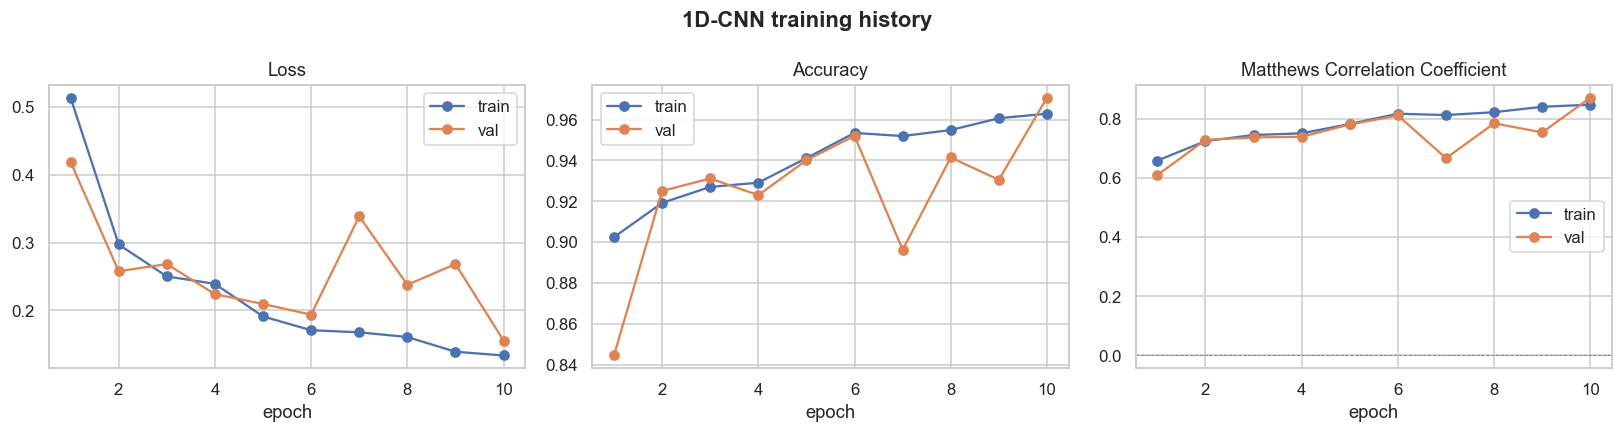

In [9]:
hist_df = pd.DataFrame(
    history,
    columns=["epoch", "tr_loss", "val_loss", "tr_acc", "val_acc", "tr_mcc", "val_mcc"]
)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist_df["epoch"], hist_df["tr_loss"], "o-", label="train")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], "o-", label="val")
axes[0].set_title("Loss")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["tr_acc"], "o-", label="train")
axes[1].plot(hist_df["epoch"], hist_df["val_acc"], "o-", label="val")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("epoch")
axes[1].legend()

axes[2].plot(hist_df["epoch"], hist_df["tr_mcc"], "o-", label="train")
axes[2].plot(hist_df["epoch"], hist_df["val_mcc"], "o-", label="val")
axes[2].set_title("Matthews Correlation Coefficient")
axes[2].set_xlabel("epoch")
axes[2].axhline(0, color="grey", ls="--", lw=0.6)
axes[2].legend()

fig.suptitle("1D-CNN training history", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "08_cnn_training_curves.png", dpi=130, bbox_inches="tight")
plt.show()

## 8. Test-set evaluation

In [10]:
def predict_probs(model, loader) -> tuple[np.ndarray, np.ndarray]:
    model.eval()
    all_p, all_y = [], []
    with torch.no_grad():
        for X_b, y_b in loader:
            logits = model(X_b.to(DEVICE))
            probs = F.softmax(logits, dim=1)
            all_p.append(probs.cpu().numpy())
            all_y.append(y_b.numpy())
    return np.concatenate(all_p, axis=0), np.concatenate(all_y, axis=0)


probs, y_true = predict_probs(model, test_loader)
pred = probs.argmax(axis=1)

mcc_cnn = matthews_corrcoef(y_true, pred)
f1m_cnn = f1_score(y_true, pred, average="macro", zero_division=0)
y_bin = label_binarize(y_true, classes=[0, 1, 2])
ap_per_class = {
    "Normal":   average_precision_score(y_bin[:, 0], probs[:, 0]),
    "Degraded": average_precision_score(y_bin[:, 1], probs[:, 1]),
    "Critical": average_precision_score(y_bin[:, 2], probs[:, 2]),
}

print(f"1D-CNN test MCC = {mcc_cnn:+.3f}")
print(f"1D-CNN test F1 macro = {f1m_cnn:.3f}")
print(f"AP per class: {ap_per_class}")
print()
print(classification_report(y_true, pred, target_names=["Normal", "Degraded", "Critical"], zero_division=0))

1D-CNN test MCC = +0.871
1D-CNN test F1 macro = 0.695
AP per class: {'Normal': 0.9997934109668056, 'Degraded': 0.09687072936851895, 'Critical': 0.992764223110369}

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     13100
    Degraded       0.08      0.64      0.14        50
    Critical       0.98      0.94      0.96      1650

    accuracy                           0.97     14800
   macro avg       0.69      0.85      0.69     14800
weighted avg       0.99      0.97      0.98     14800



## 9. Confusion matrix

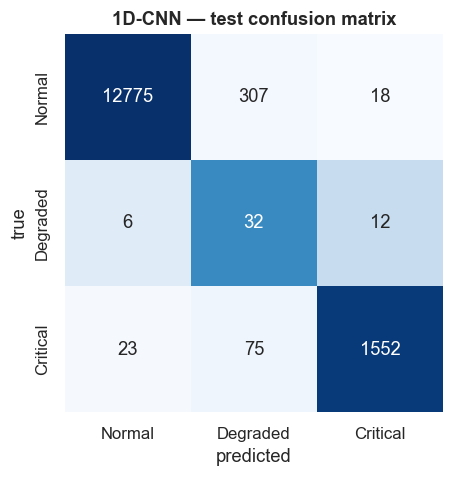

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(5, 4.5))
cm = confusion_matrix(y_true, pred, labels=[0, 1, 2])
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
sns.heatmap(
    cm_norm, annot=cm, fmt="d", cmap="Blues", ax=ax,
    xticklabels=["Normal", "Degraded", "Critical"],
    yticklabels=["Normal", "Degraded", "Critical"],
    cbar=False, square=True,
)
ax.set_title("1D-CNN — test confusion matrix", fontweight="bold")
ax.set_xlabel("predicted")
ax.set_ylabel("true")
fig.tight_layout()
fig.savefig(FIG_DIR / "09_cnn_confusion.png", dpi=130, bbox_inches="tight")
plt.show()

## 10. Side-by-side comparison with notebook 03 baselines

Place the CNN result alongside Logistic / Random Forest / XGBoost from notebook 03.

In [12]:
comparison = pd.DataFrame([
    {"model": "Logistic regression", "MCC": 0.450, "F1_macro": 0.518, "AP_Normal": 0.926, "AP_Degraded": 0.030, "AP_Critical": 0.858},
    {"model": "Random Forest",       "MCC": 0.835, "F1_macro": 0.615, "AP_Normal": 0.991, "AP_Degraded": 0.043, "AP_Critical": 0.945},
    {"model": "XGBoost",             "MCC": 0.787, "F1_macro": 0.614, "AP_Normal": 0.989, "AP_Degraded": 0.069, "AP_Critical": 0.942},
    {"model": "1D-CNN (raw signal)", "MCC": mcc_cnn, "F1_macro": f1m_cnn,
     "AP_Normal": ap_per_class["Normal"], "AP_Degraded": ap_per_class["Degraded"], "AP_Critical": ap_per_class["Critical"]},
]).set_index("model").round(3)
comparison

,MCC,F1_macro,AP_Normal,AP_Degraded,AP_Critical
model,,,,,
Logistic regression,0.450,0.518,0.926,0.030,0.858
Random Forest,0.835,0.615,0.991,0.043,0.945
XGBoost,0.787,0.614,0.989,0.069,0.942
1D-CNN (raw signal),0.871,0.695,1.000,0.097,0.993


## 11. Discussion

Three readouts that determine the project's headline narrative:

1. **Does the CNN beat the tree baselines on overall MCC?**
   If yes, the raw waveform contains signal beyond the hand-engineered features — worth flagging in the article as "deep models capture structure that band-energy features miss."
   If no, the engineered features were already complete — the negative result is also a real finding: for a clear outer-race failure like Set 2's, classical features suffice.

2. **Does the CNN crack the Degraded class?**
   The tree models had AP_Degraded ≈ 0.05. If the CNN gets AP_Degraded > 0.1, the raw waveform is encoding transient-detection signal that the windowed band energies miss. If not, the limit is the labelling — Degraded is too rare (~0.4% prevalence) and too transient for either approach.

3. **Does normalisation matter?**
   I normalised each window to zero mean / unit variance. The CNN is therefore detecting *shape*, not amplitude. Tree models had access to amplitude (env_rms, raw_rms). Comparing the two is comparing "what shape says" vs "what energy says." A surprisingly strong result for the CNN here would argue that the post-failure waveform has a recognisable temporal pattern even when its amplitude is normalised away.

**What I would do next if I had another week.**

- Train a LOBO-style protocol across all 12 bearings in Sets 1 / 2 / 3 (paper #18). The Set-2-only stratified split is a friendly testbed but doesn't measure cross-bearing generalisation.
- Replace the simple BatchNorm-1D-CNN with a 1D Self-ONN (Kılıçkaya 2022, corpus paper #1) and check whether the higher-order non-linear neurons add anything.
- Try a CNN-LSTM hybrid (corpus paper #12, Pan et al. 2024) — CNN over the window, LSTM over the 25 windows of a 1-second snapshot — to see whether temporal aggregation across windows lifts AP_Degraded.

**For the article (notebook 05).** This notebook plus notebook 03 give the four-row comparison table that anchors the results section: Logistic / RF / XGBoost / 1D-CNN. Whichever direction the CNN result lands, the story is honest and useful.